# Lattice Dynamics: 1D Monoatomic and Diatomic Chains

---

## 🔹 1. Monoatomic Linear Chain

Consider a one-dimensional chain of identical atoms:
- Mass = $M$
- Lattice spacing = $a$
- Nearest-neighbor spring constant = $K$

---

### 🔸 Equation of Motion

Using Newton’s second law:

$$
M \frac{d^2 u_n}{dt^2} = K( u_{n+1} + u_{n-1} - 2u_n )
$$

---

### 🔸 Trial Solution (Plane Wave)

Assume a travelling wave solution:

$$
u_n(t) = u_q e^{i(qna - \omega t)}
$$

---

### 🔸 Substitution

Using:
$$
u_{n+1} = u_n e^{iqa}, \quad u_{n-1} = u_n e^{-iqa}
$$

Substitute into equation:

$$
M(-\omega^2)u_n = K \left(u_n e^{iqa} + u_n e^{-iqa} - 2u_n \right)
$$

---

### 🔸 Dispersion Relation

Using $e^{iqa} + e^{-iqa} = 2\cos(qa)$:

$$
M\omega^2 = 2K(1 - \cos(qa))
$$

---

### 🔸 Alternative Form

Using identity $1 - \cos(qa) = 2\sin^2(qa/2)$:

$$
\omega(q) = 2\sqrt{\frac{K}{M}} \left|\sin\left(\frac{qa}{2}\right)\right|
$$

---

### 🔸 Key Features

- Periodic in $q$
- Maximum frequency at Brillouin zone boundary
- Long wavelength limit ($q \to 0$):
  
$$
\omega \approx v_s q
$$

where $v_s$ is speed of sound.

---

## 🔹 2. Diatomic Linear Chain

Now consider alternating atoms:
- Masses: $M_1$, $M_2$
- Same spring constant $K$

---

### 🔸 Equations of Motion

For atom 1:

$$
M_1 \frac{d^2 u_n}{dt^2} = K(v_n + v_{n-1} - 2u_n)
$$

For atom 2:

$$
M_2 \frac{d^2 v_n}{dt^2} = K(u_n + u_{n+1} - 2v_n)
$$

---

### 🔸 Trial Solutions

$$
u_n = u e^{i(qna - \omega t)}, \quad v_n = v e^{i(qna - \omega t)}
$$

---

### 🔸 Matrix Form

Substitution leads to coupled equations:

$$
\begin{pmatrix}
2K - M_1 \omega^2 & -2K\cos(qa/2) \\
-2K\cos(qa/2) & 2K - M_2 \omega^2
\end{pmatrix}
\begin{pmatrix}
u \\
v
\end{pmatrix}
= 0
$$

---

### 🔸 Dispersion Relation

Solving determinant = 0:

$$
\omega^2 = K \left( \frac{1}{M_1} + \frac{1}{M_2} \right)
\pm K \sqrt{\left( \frac{1}{M_1} + \frac{1}{M_2} \right)^2 - \frac{4\sin^2(qa/2)}{M_1 M_2}}
$$

---

### 🔸 Two Branches

#### 1. Acoustic Branch
- Lower frequency
- $\omega \to 0$ as $q \to 0$
- Atoms move **in phase**

#### 2. Optical Branch
- Higher frequency
- $\omega \neq 0$ at $q = 0$
- Atoms move **out of phase**

---

### 🔸 Key Features

- Energy gap between branches
- Optical modes interact with electromagnetic radiation
- Important in infrared and Raman spectroscopy

---

## 🔹 Summary

| Property | Monoatomic | Diatomic |
|--------|----------|---------|
| Number of branches | 1 | 2 |
| Optical mode | ❌ | ✅ |
| Acoustic mode | ✅ | ✅ |
| Gap in dispersion | ❌ | ✅ |

---

## 🔹 Physical Insight

- Monoatomic chain → simple wave propagation  
- Diatomic chain → richer physics due to mass difference  
- Leads to **phonons**, central to thermal and electronic properties

---

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


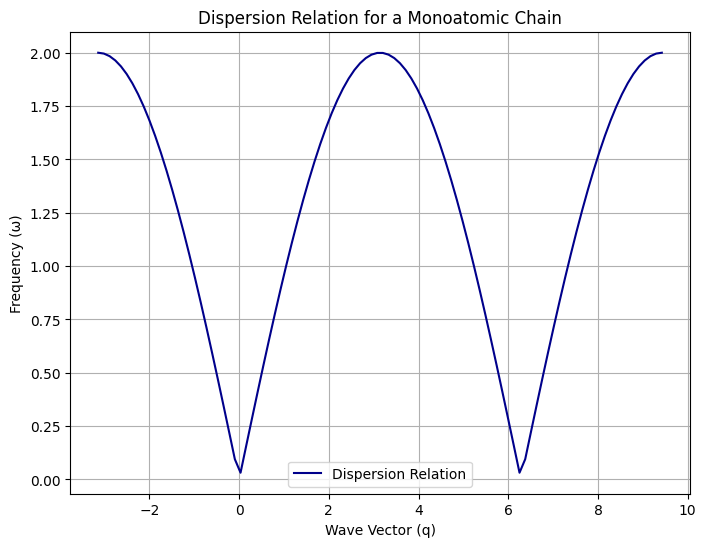

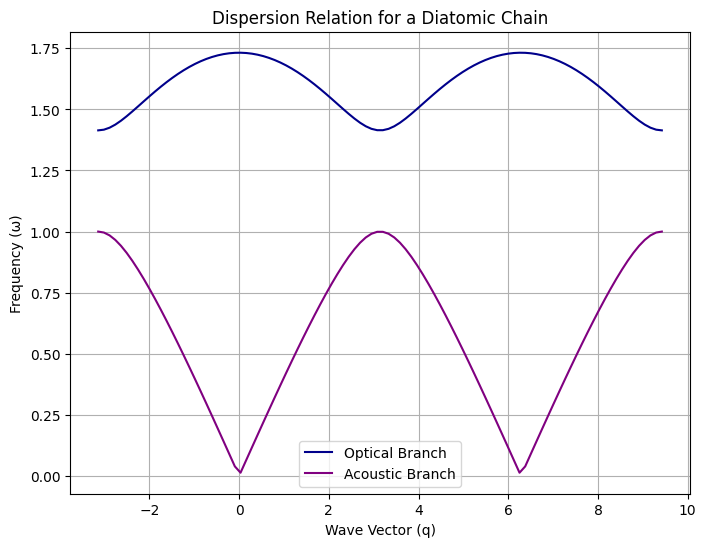

In [10]:
# Lattice dynamics in a 1D chain of atoms
# Monoatomic chain with nearest-neighbor interactions
# Parameters
N = 100  # Number of atoms
m = 1.0  # Mass of each atom
k = 1.0  # Spring constant
K = 1.0  # Force constant
a = 1.0  # Lattice constant

# Dispersion relation for a monoatomic chain
def dispersion_relation(K,k, a):
    return [2 * np.sqrt(K / m) * np.abs(np.sin(k[i] * a / 2)) for i in range(len(k))]
# Generate wave vectors
q = np.linspace(-np.pi / a, 3*np.pi / a, N)
# Calculate frequencies
frequencies = dispersion_relation(K,q, a)

# Plot the dispersion relation
plt.figure(figsize=(8, 6))
plt.plot(q, frequencies, label='Dispersion Relation',color='darkblue')
plt.title('Dispersion Relation for a Monoatomic Chain')
plt.xlabel('Wave Vector (q)')
plt.ylabel('Frequency (ω)')
plt.grid()
plt.legend()
plt.show()


# Diatomic chain with two atoms per unit cell
# Parameters
m1 = 1.0  # Mass of atom 1
m2 = 2.0  # Mass of atom 2
k1 = 1.0  # Spring constant between atom 1 and atom 2
k2 = 1.0  # Spring constant between atom 2 and atom 1
k = 1.0  # wave vector
a = 1.0  # Lattice constant

# Generate wave vectors
q = np.linspace(-np.pi / a, 3*np.pi / a, N)
# Calculate frequencies
frequencies1 = []
frequencies2 = []
for i in range(len(q)):
    D = np.array([[(k1 + k2)/m1, (-k1 * np.exp(-1j * q[i] * a) - k2)/m1], [(-k2 - k1 * np.exp(1j * q[i] * a))/m2, (k1 + k2)/m2]])
    ev2,evec2 = np.linalg.eig(D)
    frequencies1.append(np.sqrt(ev2[0])) # w+
    frequencies2.append(np.sqrt(ev2[1])) # w-
# Plot the dispersion relation
plt.figure(figsize=(8, 6))
plt.plot(q, frequencies1, label='Optical Branch',color='darkblue')
plt.plot(q, frequencies2, label='Acoustic Branch',color='purple')
plt.title('Dispersion Relation for a Diatomic Chain')
plt.xlabel('Wave Vector (q)')
plt.ylabel('Frequency (ω)')
plt.grid()
plt.legend()
plt.show()

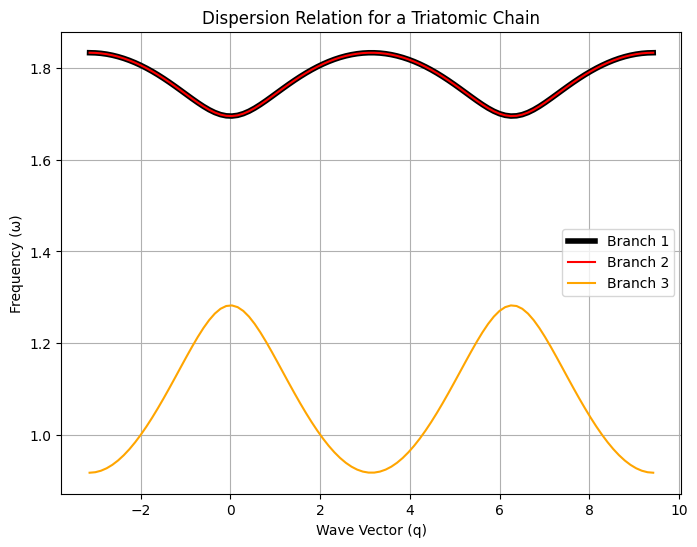

In [21]:
# Triatomic chain with three atoms per unit cell
# Parameters
m1 = 1.0  # Mass of atom 1
m2 = 2.0  # Mass of atom 2
m3 = 3.0  # Mass of atom 3
k1 = 1.0  # Spring constant between atom 1 and atom 2
k2 = 2  # Spring constant between atom 2 and atom 3
k3 = 3  # Spring constant between atom 3 and atom 1
a = 1.0  # Lattice constant
k = 1.0  # wave vector
# Generate wave vectors
q = np.linspace(-np.pi / a, 3*np.pi / a, N)
# Calculate frequencies
freq1 = []
freq2 = []
freq3 = []
for i in range(len(q)):
    D = [[(k1 + k3)/m1, k1/m1, (k3*np.exp(-1j * q[i] * a))/m1],
         [-k1/m2, (k1 + k2)/m2, -k2/m2],
         [(-k3 * np.exp(1j * q[i] * a))/m3, -k2/m3, (k2 + k3)/m3]]
    ev,evec = np.linalg.eig(D)
    freq1.append(np.sqrt(ev[0])) # w1
    freq2.append(np.sqrt(ev[1])) # w2
    freq3.append(np.sqrt(ev[2])) # w3
# Plot the dispersion relation
plt.figure(figsize=(8, 6))
plt.plot(q, freq1, label='Branch 1',color='black',linewidth=4)
plt.plot(q, freq2, label='Branch 2',color='red')
plt.plot(q, freq3, label='Branch 3',color='orange')
plt.title('Dispersion Relation for a Triatomic Chain')
plt.xlabel('Wave Vector (q)')
plt.ylabel('Frequency (ω)')
plt.grid()
plt.legend()    
plt.show()